In [112]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [113]:
df = pd.read_csv("train.csv")

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [114]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [115]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF':'Low Fat',
    'low fat':'Low Fat',
    'reg':'Regular'
})

In [116]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [117]:
df['Item_Visibility'].describe()

count    8523.000000
mean        0.066132
std         0.051598
min         0.000000
25%         0.026989
50%         0.053931
75%         0.094585
max         0.328391
Name: Item_Visibility, dtype: float64

In [118]:
df['Item_Type'].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [119]:
df.groupby('Item_Type')['Item_MRP'].mean().sort_values(ascending=False)

Item_Type
Household                149.424753
Dairy                    148.499208
Starchy Foods            147.838023
Snack Foods              146.194934
Fruits and Vegetables    144.581235
Seafood                  141.841719
Breakfast                141.788151
Breads                   140.952669
Meat                     139.882032
Canned                   139.763832
Frozen Foods             138.503366
Hard Drinks              137.077928
Others                   132.851430
Soft Drinks              131.492506
Health and Hygiene       130.818921
Baking Goods             126.380766
Name: Item_MRP, dtype: float64

In [120]:
df['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [121]:
df['Outlet_Size'].describe()

count       6113
unique         3
top       Medium
freq        2793
Name: Outlet_Size, dtype: object

In [122]:
df['Outlet_Size'].isnull().sum()

np.int64(2410)

In [123]:
df['Outlet_Size'].fillna(df.groupby('Outlet_Type')['Outlet_Size'].transform(lambda x: x.mode()[0]), inplace=True)

0       Medium
1       Medium
2       Medium
3        Small
4         High
         ...  
8518      High
8519     Small
8520     Small
8521    Medium
8522     Small
Name: Outlet_Size, Length: 8523, dtype: str

In [124]:
# Correlation (only numeric columns)
corr = df.corr(numeric_only=True)

# Print correlation with target
target_corr = corr["Item_Outlet_Sales"].sort_values(ascending=False)

print("Correlation with Target:\n")
print(target_corr)

Correlation with Target:

Item_Outlet_Sales            1.000000
Item_MRP                     0.567574
Item_Weight                  0.014123
Outlet_Establishment_Year   -0.049135
Item_Visibility             -0.128625
Name: Item_Outlet_Sales, dtype: float64


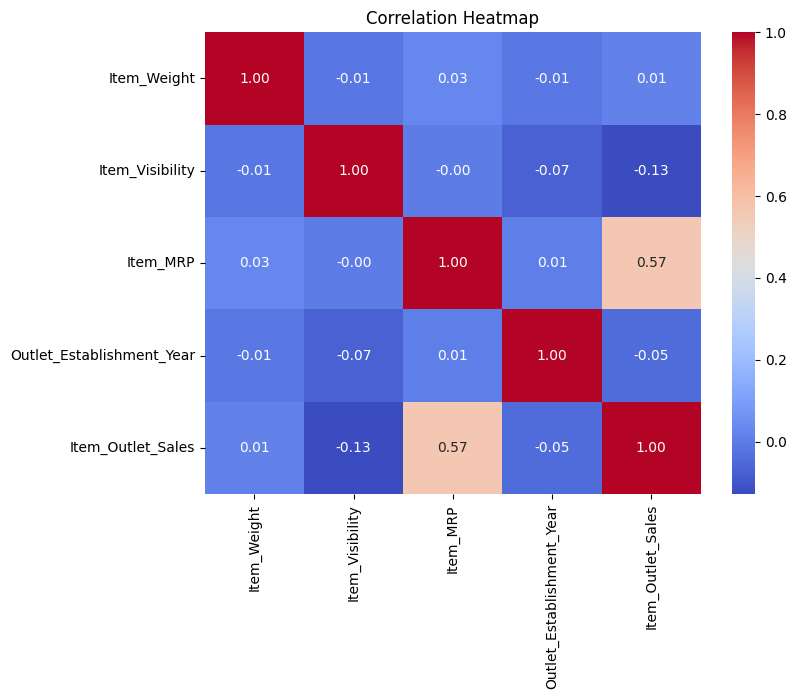

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

Handle Missing Values


In [126]:
df['Item_Weight'] = df.groupby('Item_Type')['Item_Weight']\
                      .transform(lambda x: x.fillna(x.mean()))

In [127]:
df['Item_Visibility'] = df.groupby('Item_Type')['Item_Visibility']\
                          .transform(lambda x: x.replace(0, x.mean()))

In [128]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.068513,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.061322,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [129]:
df['Item_Category'] = df['Item_Identifier'].str[:2]

df['Item_Category'] = df['Item_Category'].map({
    'FD':'Food',
    'NC':'Non-Consumable',
    'DR':'Drinks'
})




In [130]:
df.loc[df['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'

In [131]:
df['Store_Age'] = 2026 - df['Outlet_Establishment_Year']

In [132]:
df['Price_Level'] = pd.cut(df['Item_MRP'], bins=[0,70,140,210,300],
                          labels=['Low','Medium','High','Very High'])

In [133]:
visibility_mean = df.groupby('Item_Identifier')['Item_Visibility'].transform('mean')

df['Visibility_Ratio'] = df['Item_Visibility'] / visibility_mean

In [134]:
df['Item_Count'] = df.groupby('Item_Identifier')['Item_Identifier'].transform('count')

In [135]:
df.drop(['Item_Identifier','Outlet_Identifier','Outlet_Establishment_Year'], axis=1, inplace=True)

In [136]:
df = pd.get_dummies(df, drop_first=True)



In [137]:
df

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Store_Age,Visibility_Ratio,Item_Count,Item_Fat_Content_Non-Edible,Item_Fat_Content_Regular,Item_Type_Breads,...,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3,Item_Category_Food,Item_Category_Non-Consumable,Price_Level_Medium,Price_Level_High,Price_Level_Very High
0,9.300,0.016047,249.8092,3735.1380,27,0.922960,8,False,False,False,...,False,False,True,False,False,True,False,False,False,True
1,5.920,0.019278,48.2692,443.4228,17,1.003057,6,False,True,False,...,False,True,False,True,False,False,False,False,False,False
2,17.500,0.016760,141.6180,2097.2700,27,0.831990,7,False,False,False,...,False,False,True,False,False,True,False,False,True,False
3,19.200,0.068513,182.0950,732.3800,28,1.797706,6,False,True,False,...,False,True,False,False,False,True,False,False,True,False
4,8.930,0.061322,53.8614,994.7052,39,1.582785,6,True,False,False,...,False,True,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0.056783,214.5218,2778.3834,39,0.920247,8,False,False,False,...,False,True,True,False,False,True,False,False,False,True
8519,8.380,0.046982,108.1570,549.2850,24,1.000657,6,False,True,False,...,True,False,True,False,False,True,False,True,False,False
8520,10.600,0.035186,85.1224,1193.1136,22,0.999512,6,True,False,False,...,True,False,True,False,False,False,True,True,False,False
8521,7.210,0.145221,103.1332,1845.5976,17,1.101593,6,False,True,False,...,False,True,False,True,False,True,False,True,False,False


In [138]:
from sklearn.model_selection import train_test_split

X = df.drop("Item_Outlet_Sales", axis=1)
y = df["Item_Outlet_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [139]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [140]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

models = {
    "Random Forest": RandomForestRegressor(n_estimators=200),
    "Gradient Boosting": GradientBoostingRegressor()
}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    print(name, "R2 Score:", r2_score(y_test, pred))

Random Forest R2 Score: 0.5635661096963596
Gradient Boosting R2 Score: 0.6035856956842833


In [141]:
models = {

"Linear Regression": LinearRegression(),

"Decision Tree": DecisionTreeRegressor(),

"Random Forest": RandomForestRegressor(),

"Gradient Boosting": GradientBoostingRegressor(),

"SVM": SVR(),

"KNN": KNeighborsRegressor()

}

In [142]:
results = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, pred)

    results[name] = r2

    print(name, "R2 Score:", r2)

Linear Regression R2 Score: 0.5774325507530362
Decision Tree R2 Score: 0.13886849155047376
Random Forest R2 Score: 0.5626122868552146
Gradient Boosting R2 Score: 0.6028388121125221
SVM R2 Score: 0.02537012901876523
KNN R2 Score: 0.4876152756026201


In [144]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X,y)

# importances = model.feature_importances_

y_pred = model.predict(X_test)
print("R2:",r2_score(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred))

R2: 0.938658203859521
RMSE: 166725.1657423271
